In [1]:
# ============================================
# NOTEBOOK 3: VISUALISATION
# Building professional football pitch
# visualisations using mplsoccer
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import Pitch, VerticalPitch
import warnings
warnings.filterwarnings('ignore')

# Load feature matrix
shots = pd.read_csv('../data/shots_features.csv')

print("Libraries loaded")
print(f"Shots loaded: {len(shots)}")
print(f"Goals: {shots['is_goal'].sum()}")

Libraries loaded
Shots loaded: 839
Goals: 111


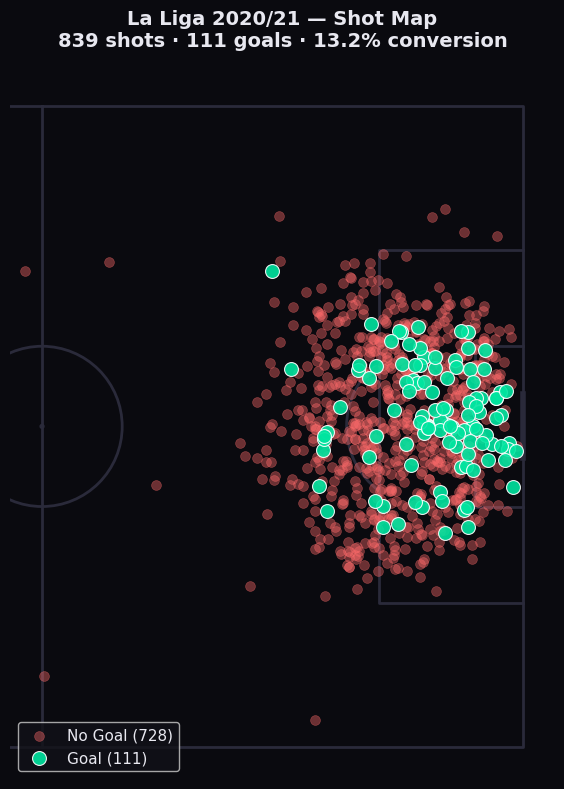

Shot map saved


In [2]:
# ============================================
# CHART 1: SHOT MAP
# Every shot plotted on a pitch diagram
# Green = Goal, Red = No Goal
# Size = shot distance (closer = bigger dot)
# ============================================

pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='#0a0a0f',
    line_color='#2a2a3a',
    half=True  # show attacking half only
)

fig, ax = pitch.draw(figsize=(12, 8))
fig.patch.set_facecolor('#0a0a0f')

# Plot non-goals first (so goals appear on top)
non_goals = shots[shots['is_goal'] == 0]
goals = shots[shots['is_goal'] == 1]

pitch.scatter(
    non_goals['x'], non_goals['y'],
    ax=ax,
    s=50,
    color='#ff6b6b',
    alpha=0.4,
    edgecolors='#ff6b6b',
    linewidth=0.5,
    label=f'No Goal ({len(non_goals)})'
)

pitch.scatter(
    goals['x'], goals['y'],
    ax=ax,
    s=100,
    color='#00e5a0',
    alpha=0.9,
    edgecolors='white',
    linewidth=0.8,
    label=f'Goal ({len(goals)})'
)

ax.set_title('La Liga 2020/21 — Shot Map\n839 shots · 111 goals · 13.2% conversion',
             color='#e8e8f0', fontsize=14, fontweight='bold', pad=20)

ax.legend(loc='lower left', facecolor='#111118',
          labelcolor='#e8e8f0', fontsize=11)

plt.tight_layout()
plt.savefig('../reports/shot_map.png', dpi=300,
            bbox_inches='tight', facecolor='#0a0a0f')
plt.show()
print("Shot map saved")

In [3]:
observation_1 = """
CHART 1 FINDING: Shot Map — La Liga 2020/21
============================================
- 839 total shots plotted across 35 matches
- Goals (green) clearly cluster close to goal
- Missed shots (red) spread much wider and
  further from goal
- Very few goals scored outside the penalty area
- The penalty spot area shows the highest
  concentration of goals

INSIGHT: The visual confirms our mathematical
finding — goals are scored significantly closer
to goal and from more central positions.
This spatial pattern is the foundation of xG.
"""
print(observation_1)


CHART 1 FINDING: Shot Map — La Liga 2020/21
- 839 total shots plotted across 35 matches
- Goals (green) clearly cluster close to goal
- Missed shots (red) spread much wider and
  further from goal
- Very few goals scored outside the penalty area
- The penalty spot area shows the highest
  concentration of goals

INSIGHT: The visual confirms our mathematical
finding — goals are scored significantly closer
to goal and from more central positions.
This spatial pattern is the foundation of xG.



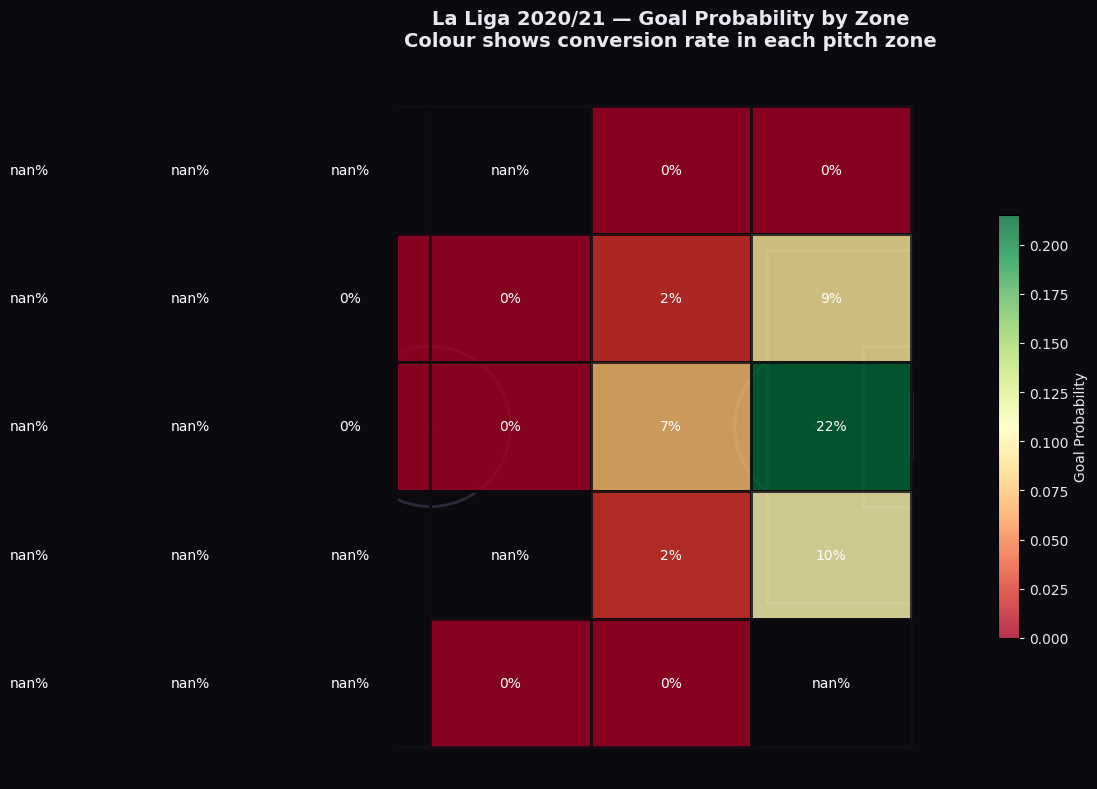

Heatmap saved


In [4]:
# ============================================
# CHART 2: GOAL PROBABILITY HEATMAP
# Divides the pitch into zones and shows
# the conversion rate in each zone
# ============================================

pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='#0a0a0f',
    line_color='#2a2a3a',
    half=True
)

fig, ax = pitch.draw(figsize=(12, 8))
fig.patch.set_facecolor('#0a0a0f')

# Create heatmap using bin statistics
bin_statistic = pitch.bin_statistic(
    shots['x'], shots['y'],
    values=shots['is_goal'],
    statistic='mean',
    bins=(6, 5)
)

# Draw the heatmap
heatmap = pitch.heatmap(
    bin_statistic,
    ax=ax,
    cmap='RdYlGn',
    alpha=0.8,
    edgecolors='#0a0a0f',
    linewidth=2
)

# Add percentage labels in each zone
pitch.label_heatmap(
    bin_statistic,
    color='white',
    fontsize=10,
    ax=ax,
    ha='center',
    va='center',
    str_format='{:.0%}'
)

# Add colorbar
cbar = fig.colorbar(heatmap, ax=ax, shrink=0.6)
cbar.set_label('Goal Probability', color='#e8e8f0')
cbar.ax.yaxis.set_tick_params(color='#e8e8f0')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#e8e8f0')

ax.set_title('La Liga 2020/21 — Goal Probability by Zone\n'
             'Colour shows conversion rate in each pitch zone',
             color='#e8e8f0', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../reports/goal_probability_heatmap.png',
            dpi=300, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()
print("Heatmap saved")

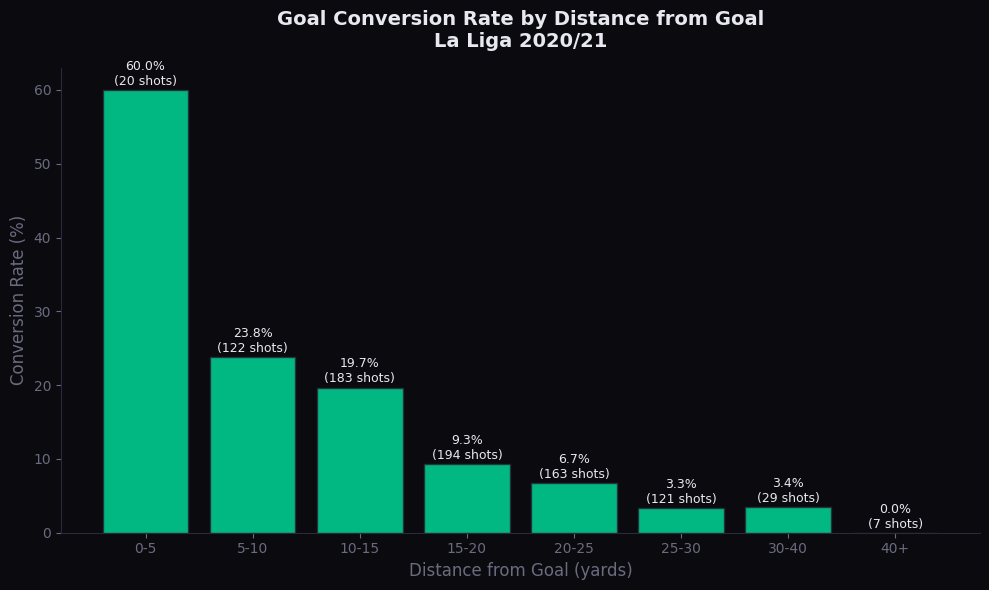

Chart 3 saved


In [5]:
# ============================================
# CHART 3: DISTANCE VS GOAL PROBABILITY
# Shows how goal probability drops as
# distance from goal increases
# ============================================

# Create distance bands
shots['distance_band'] = pd.cut(
    shots['distance'],
    bins=[0, 5, 10, 15, 20, 25, 30, 40, 100],
    labels=['0-5', '5-10', '10-15', '15-20',
            '20-25', '25-30', '30-40', '40+']
)

# Calculate conversion rate per band
conv_by_distance = shots.groupby(
    'distance_band', observed=True
)['is_goal'].agg(['mean', 'count']).reset_index()
conv_by_distance.columns = ['distance_band',
                             'conversion_rate', 'shots']
conv_by_distance['conversion_pct'] = (
    conv_by_distance['conversion_rate'] * 100
)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0a0a0f')
ax.set_facecolor('#0a0a0f')

bars = ax.bar(
    conv_by_distance['distance_band'],
    conv_by_distance['conversion_pct'],
    color='#00e5a0',
    alpha=0.8,
    edgecolor='#2a2a3a'
)

# Add count labels
for bar, (_, row) in zip(bars, conv_by_distance.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f"{row['conversion_pct']:.1f}%\n({int(row['shots'])} shots)",
        ha='center', va='bottom',
        color='#e8e8f0', fontsize=9
    )

ax.set_title('Goal Conversion Rate by Distance from Goal\n'
             'La Liga 2020/21',
             color='#e8e8f0', fontsize=14,
             fontweight='bold', pad=15)
ax.set_xlabel('Distance from Goal (yards)',
              color='#6b6b80', fontsize=12)
ax.set_ylabel('Conversion Rate (%)',
              color='#6b6b80', fontsize=12)
ax.tick_params(colors='#6b6b80')
ax.spines['bottom'].set_color('#2a2a3a')
ax.spines['left'].set_color('#2a2a3a')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/distance_vs_conversion.png',
            dpi=300, bbox_inches='tight',
            facecolor='#0a0a0f')
plt.show()
print("Chart 3 saved")

In [6]:
summary = """
SUMMARY — Visualisations Complete
========================================

CHART 1: Shot Map
- 839 shots plotted on professional pitch diagram
- Goals clearly cluster close to and central to goal
- Confirms spatial pattern mathematically found in Day 3

CHART 2: Goal Probability Heatmap
- Central zone closest to goal: 22% conversion rate
- Wide zones and far zones: 0-2% conversion rate
- Clear visual proof that location determines xG

CHART 3: Distance vs Conversion Rate
- 0-5 yards:   60.0% — tap-ins almost always score
- 5-10 yards:  23.8% — close range, high quality
- 10-15 yards: 19.7% — penalty area shots
- 20-25 yards:  6.7% — drops sharply with distance
- 40+ yards:    0.0% — nobody scores from here

KEY INSIGHT:
Moving back just 20 yards reduces goal probability
by 9x (60% to 6.7%). This dramatic relationship
between distance and goal probability is the
mathematical foundation of the xG model.
"""
print(summary)


SUMMARY — Visualisations Complete

CHART 1: Shot Map
- 839 shots plotted on professional pitch diagram
- Goals clearly cluster close to and central to goal
- Confirms spatial pattern mathematically found in Day 3

CHART 2: Goal Probability Heatmap
- Central zone closest to goal: 22% conversion rate
- Wide zones and far zones: 0-2% conversion rate
- Clear visual proof that location determines xG

CHART 3: Distance vs Conversion Rate
- 0-5 yards:   60.0% — tap-ins almost always score
- 5-10 yards:  23.8% — close range, high quality
- 10-15 yards: 19.7% — penalty area shots
- 20-25 yards:  6.7% — drops sharply with distance
- 40+ yards:    0.0% — nobody scores from here

KEY INSIGHT:
Moving back just 20 yards reduces goal probability
by 9x (60% to 6.7%). This dramatic relationship
between distance and goal probability is the
mathematical foundation of the xG model.

